<a href="https://colab.research.google.com/github/Arpit-oo/CC-Assignments/blob/main/assignment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1.  Write a unique paragraph (5-6 sentences) about your favorite topic (e.g., sports,
technology, food, books, etc.).
1. Convert text to lowercase and remove punctuation.
2. Tokenize the text into words and sentences.
3. Remove stopwords (using NLTK's stopwords list).
4. Display word frequency distribution (excluding stopwords).

In [1]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

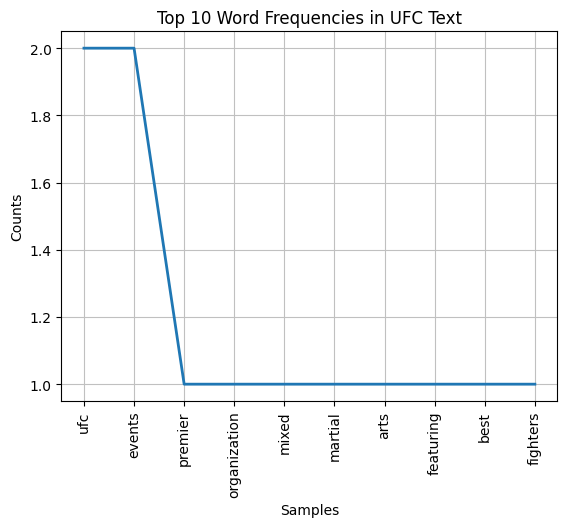

In [2]:
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.probability import FreqDist
import matplotlib.pyplot as plt

text = '''The UFC is the premier organization in mixed martial arts, featuring the best fighters in the world.
Events are held globally, showcasing bouts across multiple weight divisions.
Champions like Jon Jones, Israel Adesanya, and Amanda Nunes have become household names.
The sport blends striking and grappling disciplines such as boxing, wrestling, Muay Thai, and Brazilian Jiu-Jitsu.
Pay-per-view events draw millions of viewers, highlighting the UFC’s massive global influence.
Training camps, weigh-ins, and press conferences build anticipation before major fight nights.'''

text = text.lower().translate(str.maketrans('', '', string.punctuation))

words = word_tokenize(text)
sentences = sent_tokenize(text)

stopword_list = set(stopwords.words('english'))
meaningful_words = [token for token in words if token not in stopword_list]

frequency_distribution = FreqDist(meaningful_words)

frequency_distribution.plot(10, title="Top 10 Word Frequencies in UFC Text")
plt.show()



Q2: Stemming and Lemmatization
1. Take the tokenized words from Ques on 1 (after stopword removal).
2. Apply stemming using NLTK's PorterStemmer and LancasterStemmer.
3. Apply lemmatization on using NLTK's WordNetLemmatizer.
4. Compare and display results of both techniques.

In [3]:
from nltk.stem import PorterStemmer, LancasterStemmer, WordNetLemmatizer

porter_stemmer = PorterStemmer()
lancaster_stemmer = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

porter_results = [porter_stemmer.stem(word) for word in meaningful_words]
lancaster_results = [lancaster_stemmer.stem(word) for word in meaningful_words]
lemmatized_words = [lemmatizer.lemmatize(word) for word in meaningful_words]

for word, porter, lancaster, lemma in zip(meaningful_words, porter_results, lancaster_results, lemmatized_words):
    print(f"{word:15} | Porter: {porter:15} | Lancaster: {lancaster:15} | Lemma: {lemma}")


ufc             | Porter: ufc             | Lancaster: ufc             | Lemma: ufc
premier         | Porter: premier         | Lancaster: premy           | Lemma: premier
organization    | Porter: organ           | Lancaster: org             | Lemma: organization
mixed           | Porter: mix             | Lancaster: mix             | Lemma: mixed
martial         | Porter: martial         | Lancaster: mart            | Lemma: martial
arts            | Porter: art             | Lancaster: art             | Lemma: art
featuring       | Porter: featur          | Lancaster: feat            | Lemma: featuring
best            | Porter: best            | Lancaster: best            | Lemma: best
fighters        | Porter: fighter         | Lancaster: fight           | Lemma: fighter
world           | Porter: world           | Lancaster: world           | Lemma: world
events          | Porter: event           | Lancaster: ev              | Lemma: event
held            | Porter: held            

Q3. Regular Expressions and Text Splitting
1. Take their original text from Ques on 1.
2. Use regular expressions to:
a. Extract all words with more than 5 letters.
b. Extract all numbers (if any exist in their text).
c. Extract all capitalized words.
3. Use text splitting techniques to:
a. Split the text into words containing only alphabets (removing digits and special characters).
b. Extract words starting with a vowel.

In [4]:
import re

long_words = re.findall(r'\b\w{6,}\b', text)
numeric_values = re.findall(r'\b\d+\b', text)
capitalized_terms = re.findall(r'\b[A-Z][a-z]*\b', text)
alphabetic_only = re.findall(r'\b[a-zA-Z]+\b', text)
vowel_starting = [word for word in alphabetic_only if re.match(r'^[AEIOUaeiou]', word)]

print("Words longer than 5 letters:", long_words)
print("Numeric values:", numeric_values)
print("Capitalized terms:", capitalized_terms)
print("Alphabetic words:", alphabetic_only)
print("Words starting with a vowel:", vowel_starting)


Words longer than 5 letters: ['premier', 'organization', 'martial', 'featuring', 'fighters', 'events', 'globally', 'showcasing', 'across', 'multiple', 'weight', 'divisions', 'champions', 'israel', 'adesanya', 'amanda', 'become', 'household', 'blends', 'striking', 'grappling', 'disciplines', 'boxing', 'wrestling', 'brazilian', 'jiujitsu', 'payperview', 'events', 'millions', 'viewers', 'highlighting', 'massive', 'global', 'influence', 'training', 'weighins', 'conferences', 'anticipation', 'before', 'nights']
Numeric values: []
Capitalized terms: []
Alphabetic words: ['the', 'ufc', 'is', 'the', 'premier', 'organization', 'in', 'mixed', 'martial', 'arts', 'featuring', 'the', 'best', 'fighters', 'in', 'the', 'world', 'events', 'are', 'held', 'globally', 'showcasing', 'bouts', 'across', 'multiple', 'weight', 'divisions', 'champions', 'like', 'jon', 'jones', 'israel', 'adesanya', 'and', 'amanda', 'nunes', 'have', 'become', 'household', 'names', 'the', 'sport', 'blends', 'striking', 'and', 'gr

Q4. Custom Tokenization on & Regex-based Text Cleaning
1. Take original text from Ques on 1.
2. Write a custom tokenization on func on that:
a. Removes punctuation and special symbols, but keeps contractions (e.g., "isn't" should not be split into "is" and "n't").
b. Handles hyphenated words as a single token (e.g., "state-of-the-art" remains a single token).
c. Tokenizes numbers separately but keeps decimal numbers intact (e.g., "3.14" should remain as is).

3. Use Regex Substitutions (re.sub) to:
a. Replace email addresses with '<EMAIL>' placeholder.
b. Replace URLs with '<URL>' placeholder.
c. Replace phone numbers (formats: 123-456-7890 or +91 9876543210) with '<PHONE>' placeholder.

In [5]:
def tokenize_custom(input_text):
    token_pattern = r"\b\w+(?:-\w+)*'\w+|\b\w+(?:-\w+)*|\d+\.\d+|\d+"
    return re.findall(token_pattern, input_text)

def replace_emails(input_text):
    return re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '<EMAIL>', input_text)

def replace_urls(input_text):
    return re.sub(r'https?://\S+|www\.\S+', '<URL>', input_text)

def replace_phone_numbers(input_text):
    return re.sub(r'(\+?\d{1,3}[ -]?)?\(?\d{3}\)?[ -]?\d{3}[ -]?\d{4}', '<PHONE>', input_text)

sanitized_text = replace_emails(text)
sanitized_text = replace_urls(sanitized_text)
sanitized_text = replace_phone_numbers(sanitized_text)

custom_tokens = tokenize_custom(sanitized_text)

print("Custom Tokens:", custom_tokens)


Custom Tokens: ['the', 'ufc', 'is', 'the', 'premier', 'organization', 'in', 'mixed', 'martial', 'arts', 'featuring', 'the', 'best', 'fighters', 'in', 'the', 'world', 'events', 'are', 'held', 'globally', 'showcasing', 'bouts', 'across', 'multiple', 'weight', 'divisions', 'champions', 'like', 'jon', 'jones', 'israel', 'adesanya', 'and', 'amanda', 'nunes', 'have', 'become', 'household', 'names', 'the', 'sport', 'blends', 'striking', 'and', 'grappling', 'disciplines', 'such', 'as', 'boxing', 'wrestling', 'muay', 'thai', 'and', 'brazilian', 'jiujitsu', 'payperview', 'events', 'draw', 'millions', 'of', 'viewers', 'highlighting', 'the', 'ufc', 's', 'massive', 'global', 'influence', 'training', 'camps', 'weighins', 'and', 'press', 'conferences', 'build', 'anticipation', 'before', 'major', 'fight', 'nights']
